In [1]:
from spatialx_transform.params import AffineParams
from spatialx_transform.transforms import Affine, Transformation
from spatialx_transform.point import Point
import cv2 as cv
import numpy as np
import math

In [2]:
img = cv.imread('input.png')

[ WARN:0@0.018] global loadsave.cpp:278 findDecoder imread_('input.png'): can't open/read file: check file path/integrity


In [3]:
img.shape

AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
tf = Transformation.model_validate(
    {
        "transformation_type": "composed",
        "params": {
            "transforms": [
                {
                    "transformation_type": "affine",
                    "params": {
                        "A": [[0.7071, -0.7071],
                              [0.7071,  0.7071]],
                        "b": [0, 0],
                    },
                },
                {
                    "transformation_type": "square",
                    "params": None,
                },
            ],
        },
    }
)

In [ ]:
def warp_transform(img, tf : Transformation, dx : np.int32, dy : np.int32, scale : np.float32):
    H_src = img.shape[0]
    W_src = img.shape[1]

    offsetX, offsetY = 1e9, 1e9
    maxX, maxY = -1e9, -1e9

    # Forward bbox from 4 corners only (exact for affine, good approx for TPS/composed)
    corners = [(0, 0), (W_src - 1, 0), (0, H_src - 1), (W_src - 1, H_src - 1)]
    for cx, cy in corners:
        fw_point = tf.transform(Point([cx, cy]))
        px = fw_point.x * scale
        py = fw_point.y * scale
        offsetX = min(offsetX, py)
        offsetY = min(offsetY, px)
        maxX = max(maxX, py)
        maxY = max(maxY, px)
    
    W_dst = np.int32(maxY - offsetY) + 5
    H_dst = np.int32(maxX - offsetX) + 5
    img_output = np.zeros((H_dst, W_dst, 3), dtype = np.uint8)

    # rounding offset
    offsetX = math.floor(offsetX)
    offsetY = math.floor(offsetY)

    approximated_X = list(range(0, H_src, dx))
    approximated_Y = list(range(0, W_src, dy))

    if approximated_X[-1] != H_src - 1:
        approximated_X.append(H_src - 1)
    if approximated_Y[-1] != W_src - 1:
        approximated_Y.append(W_src - 1)
    
    nx, ny = len(approximated_X), len(approximated_Y)
    trans_point = np.zeros((nx, ny), dtype = Point)

    for i in range(nx):
        for j in range(ny):
            x = approximated_X[i]
            y = approximated_Y[j]
            trans_point[i, j] = tf.transform(Point([y, x]))
    
    srcTriangle = []
    dstTriangle = []

    for i in range(nx - 1):
        for j in range(ny - 1):
            # top - left
            srcTriangle.append([
                Point([approximated_Y[j], approximated_X[i]]),
                Point([approximated_Y[j + 1], approximated_X[i]]),
                Point([approximated_Y[j], approximated_X[i + 1]]),
                ])
            dstTriangle.append([
                trans_point[i][j],
                trans_point[i][j + 1],
                trans_point[i + 1][j]
            ])
            # bottom - right
            srcTriangle.append([
                Point([approximated_Y[j + 1], approximated_X[i + 1]]),
                Point([approximated_Y[j + 1], approximated_X[i]]),
                Point([approximated_Y[j], approximated_X[i + 1]]),
                ])
            dstTriangle.append([
                trans_point[i + 1][j + 1],
                trans_point[i][j + 1],
                trans_point[i + 1][j]
            ])
    
    for i in range(len(srcTriangle)):
        dst_pts = np.array([[p.x * scale - offsetY, p.y * scale - offsetX] for p in dstTriangle[i]], dtype = np.float32)
        src_pts = np.array([[p.x, p.y] for p in srcTriangle[i]], dtype = np.float32)

        
        x_src, y_src, w_src, h_src = cv.boundingRect(src_pts)
        x_dst, y_dst, w_dst, h_dst = cv.boundingRect(dst_pts)

        if w_src == 0 or h_src == 0 or w_dst == 0 or h_dst == 0:
            continue
    
        src_local = src_pts - np.array([x_src, y_src], dtype = np.float32)
        dst_local = dst_pts - np.array([x_dst, y_dst], dtype = np.float32)

        M = cv.getAffineTransform(dst_local, src_local)

        src_crop = img[y_src:y_src + h_src, x_src:x_src + w_src]

        warped = cv.warpAffine(
            src_crop,
            M,
            (w_dst, h_dst),
            flags=cv.INTER_NEAREST | cv.WARP_INVERSE_MAP, 
            borderMode=cv.BORDER_REFLECT101,
        )
        
        mask = np.zeros((h_dst, w_dst), dtype=np.uint8)
        cv.fillConvexPoly(mask, np.int32(dst_local), 255, cv.LINE_AA)

        roi = img_output[y_dst:y_dst + h_dst, x_dst:x_dst + w_dst] 
        idx = mask > 0
        roi[idx] = warped[idx]
    
    cv.imwrite('output.png', img_output)

    return img_output

warp_transform(img, tf, 1, 1, 1)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(852, 179402, 3), dtype=uint8)

In [ ]:
import json
import zarr
import matplotlib.pyplot as plt

DATA_DIR = '/home/quan.lt/scratch/spatialx-transform/data/SP-01KT6BDYQXQ0HJZG9KH4X49V3R'
IMG1_DIR = f'{DATA_DIR}/images/1780477267_b36af349f949465f95666fcca7c027f1'
IMG2_DIR = f'{DATA_DIR}/images/1781249260_425411201fd949ec8ba49770dc4615d5'

# --- Flag: 1 = crop img2 around TPS control point, 0 = use full img2 ---
IS_CROP = 1

# --- Load active alignment transform from img2's alignment metadata ---
with open(f'{IMG2_DIR}/alignment/zarr.json') as f:
    aln_meta = json.load(f)
active_aln_id = aln_meta['attributes']['active_alignment_id']
with open(f'{IMG2_DIR}/alignment/{active_aln_id}/zarr.json') as f:
    aln_data = json.load(f)
align_tf = Transformation.model_validate(aln_data['attributes']['transformation'])
print(f'Loaded transform: {aln_data["attributes"]["transformation"]["transformation_type"]}')
print(f'Active alignment ID: {active_aln_id}')

# --- Load img2 at level 0 (full resolution) ---
# img2 shape: [1, 13921, 42636] -> (channels, rows, cols)
z_img2 = zarr.open(f'{IMG2_DIR}/0', mode='r')
print(f'img2 level 0 shape: {z_img2.shape}')

if IS_CROP:
    # Crop around TPS control point #1: (col=3712, row=7563)
    CROP_SIZE = 1000
    crop_col, crop_row = 3712, 7563
    col0 = crop_col - CROP_SIZE // 2
    row0 = crop_row - CROP_SIZE // 2
    img2_crop = z_img2[0, row0:row0+CROP_SIZE, col0:col0+CROP_SIZE]  # channel 0
    print(f'img2 crop shape: {img2_crop.shape}, dtype: {img2_crop.dtype}')
else:
    # Load full img2 (WARNING: 13921 x 42636 = ~594M pixels, very slow)
    col0, row0 = 0, 0
    img2_crop = z_img2[0, :, :]  # channel 0, full image
    print(f'img2 full shape: {img2_crop.shape}, dtype: {img2_crop.dtype}')

# Normalize to uint8 3-channel for warp_transform
img2_u8 = ((img2_crop - img2_crop.min()) / max(1, img2_crop.max() - img2_crop.min()) * 255).astype(np.uint8)
img2_u8 = np.stack([img2_u8]*3, axis=-1)
print(f'img2_u8 shape: {img2_u8.shape}')

Loaded transform: composed
Active alignment ID: aln_5409f64a3700abd84beb779ae2854d94
img2 level 0 shape: (1, 13921, 42636)
img2 crop shape: (1000, 1000), dtype: uint16
img2_u8 shape: (1000, 1000, 3)


In [ ]:
from spatialx_transform.transforms import Composed
from spatialx_transform.params import ComposedParams, AffineParams

# Build the transform to use for warping:
#   IS_CROP=1: crop-local coords --(translation)--> full img2 coords --(align_tf)--> full img1 coords
#   IS_CROP=0: full img2 coords --(align_tf)--> full img1 coords (no offset needed)
if IS_CROP:
    offset_tf = Affine(params=AffineParams(A=[[1.0, 0.0], [0.0, 1.0]], b=[float(col0), float(row0)]))
    crop_tf = Composed(params=ComposedParams(transforms=[offset_tf, align_tf]))
    print(f'Crop offset: col0={col0}, row0={row0}')
else:
    crop_tf = align_tf
    print('No crop, using align_tf directly')

# Sanity check: transform image center -> should land in img1 space
center = Point([img2_u8.shape[1] // 2, img2_u8.shape[0] // 2])
mapped = crop_tf.transform(center)
print(f'Image center -> img1 coords: ({mapped.x:.1f}, {mapped.y:.1f})')

Crop offset: col0=3212, row0=7063
Crop center -> img1 coords: (25160.8, 36137.7)


In [ ]:
# Run warp_transform on the img2 crop
# dx=10, dy=10: coarse grid step for triangle mesh
result = warp_transform(img2_u8, crop_tf, 10, 10, 1.0)
print(f'Output shape: {result.shape}')

Output shape: (7117, 2958, 3)


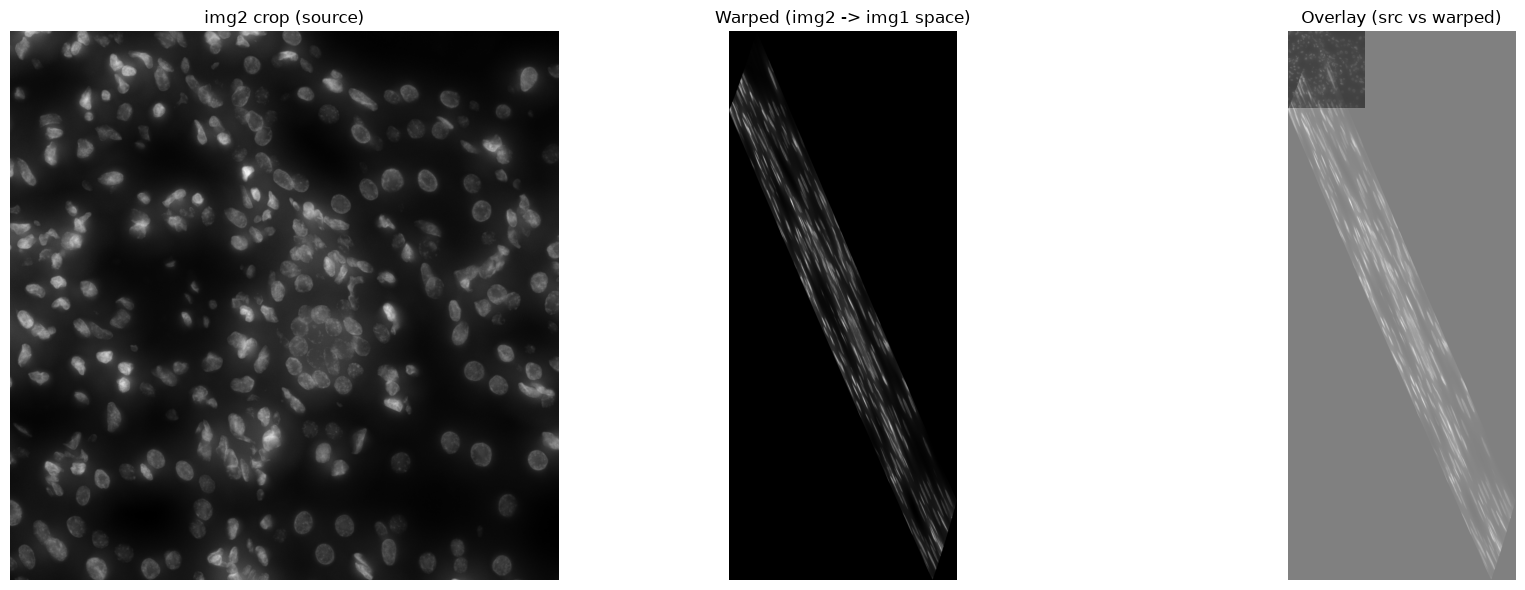

In [ ]:
# Visualize: source crop | warped result | overlay
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img2_u8)
axes[0].set_title('img2 crop (source)')
axes[1].imshow(result)
axes[1].set_title('Warped (img2 -> img1 space)')
axes[2].imshow(img2_u8, alpha=0.5)
axes[2].imshow(result, alpha=0.5)
axes[2].set_title('Overlay (src vs warped)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig('warp_result.png', dpi=150)
plt.show()

img1 level 0 shape: (5, 93876, 38305)
img1 crop shape: (1000, 1000)


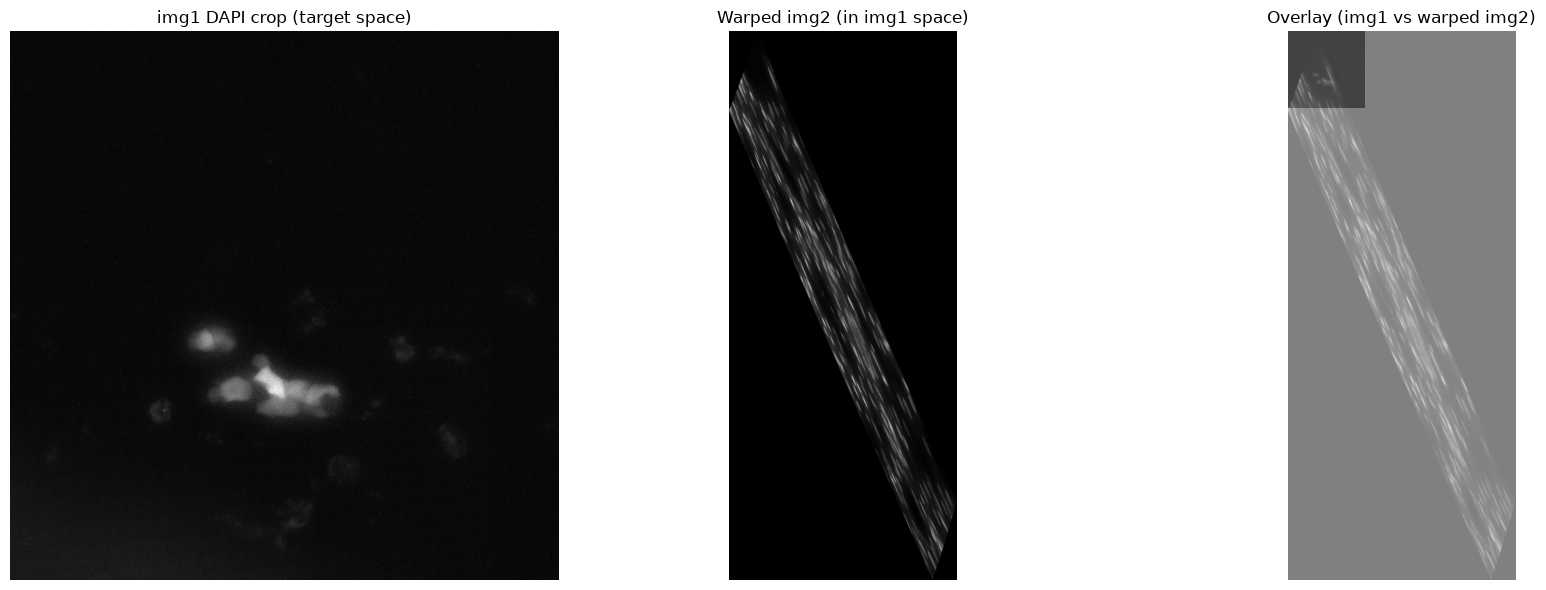

In [ ]:
# Load corresponding img1 region for alignment verification
# img1 shape: [5, 93876, 38305] -> DAPI is channel 4
# Use the mapped center coords to determine the img1 crop region
img1_cx, img1_cy = int(mapped.x), int(mapped.y)
COMPARE_SIZE = 1000
i1_col0 = max(0, img1_cx - COMPARE_SIZE // 2)
i1_row0 = max(0, img1_cy - COMPARE_SIZE // 2)

z_img1 = zarr.open(f'{IMG1_DIR}/0', mode='r')
print(f'img1 level 0 shape: {z_img1.shape}')
img1_crop = z_img1[4, i1_row0:i1_row0+COMPARE_SIZE, i1_col0:i1_col0+COMPARE_SIZE]  # DAPI channel
print(f'img1 crop shape: {img1_crop.shape}')

img1_u8 = ((img1_crop - img1_crop.min()) / max(1, img1_crop.max() - img1_crop.min()) * 255).astype(np.uint8)
img1_u8 = np.stack([img1_u8]*3, axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img1_u8)
axes[0].set_title(f'img1 DAPI crop (target space)')
axes[1].imshow(result)
axes[1].set_title('Warped img2 (in img1 space)')
axes[2].imshow(img1_u8, alpha=0.5)
axes[2].imshow(result, alpha=0.5)
axes[2].set_title('Overlay (img1 vs warped img2)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.savefig('alignment_check.png', dpi=150)
plt.show()